# Descriptive Statistics with Python 
 
[youtube video link] https://youtu.be/_TE2tOjpTbg?si=zikV6t1pszYl3N5_

In [70]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [24]:
afl_margins = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_margins.csv')
afl_margins

,afl.margins
0,56
1,31
2,56
3,8
4,32
...,...
171,28
172,38
173,29
174,10


In [25]:
afl_finalists = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/afl_finalists.csv')
afl_finalists

,afl.finalists
0,Hawthorn
1,Melbourne
2,Carlton
3,Melbourne
4,Hawthorn
...,...
395,Sydney
396,Geelong
397,Western Bulldogs
398,St Kilda


# 1. Central Tendency

### 1.1 Mean

In [5]:
margins = afl_margins['afl.margins']
print(margins[0:5].mean())

36.6


### 1.1.1 Trimmed Mean

In [7]:
dataset = [-15, 2, 3, 4, 5, 6, 7, 8, 9, 12]
dataset

[-15, 2, 3, 4, 5, 6, 7, 8, 9, 12]

In [10]:
import statistics
print(statistics.mean(dataset))

4.1


In [15]:
from scipy import stats

print(stats.trim_mean(dataset, 0.1))

5.5


## 1.2 Median

In [16]:
print(margins.median())

30.5


### 1.3 Mode

In [28]:
finalists = afl_finalists['afl.finalists']
print(finalists.value_counts())

afl.finalists
Geelong             39
West Coast          38
Essendon            32
Melbourne           28
Collingwood         28
North Melbourne     28
Hawthorn            27
Carlton             26
Sydney              26
Adelaide            26
Brisbane            25
St Kilda            24
Western Bulldogs    24
Port Adelaide       17
Richmond             6
Fremantle            6
Name: count, dtype: int64


In [29]:
print(finalists.mode())

0    Geelong
Name: afl.finalists, dtype: object


# 2. Variability

### 2.1 Range

In [30]:
print(margins.max() - margins.min())

116

### 2.2 Interquartile Range (IQR)

In [32]:
print(np.quantile(margins, 0.5)) 

30.5


In [33]:
print(np.quantile(margins, [0.25, 0.75])) 

[12.75 50.5 ]


In [36]:
# scipy library သုံးခြင်း
from scipy import stats
print(stats.iqr(margins))

37.75


### 2.3 Mean Absolute Deviation

In [44]:
avg_margin = margins[0:5].mean()
print(avg_margin)

36.6


In [45]:
MAD = (margins[0:5] - avg_margin).abs().mean()
print(MAD)

15.52


### 2.4 Variance (Mean Squared Deviation)

In [48]:
print(margins[0:5].var())

405.8


### 2.5 Standard Deviation (Square Root of Variance)

In [49]:
print(margins[0:5].std())

20.144478151592807


### 2.6 Skewness

In [51]:
print(margins.skew())

0.7804075289401982


### 2.7 Kurtosis

In [53]:
print(margins.kurtosis())

0.10109718805638757


### 2.8 Standard Scores (z-scores)

In [56]:
data = pd.Series([10, 12, 23, 23, 16, 23, 21, 16])
print(data)

0    10
1    12
2    23
3    23
4    16
5    23
6    21
7    16
dtype: int64


In [57]:
z_scores = stats.zscore(data)
print(z_scores)

0   -1.632993
1   -1.224745
2    1.020621
3    1.020621
4   -0.408248
5    1.020621
6    0.612372
7   -0.408248
dtype: float64


# Overall Summary of a variable

In [58]:
afl_margins.describe()

,afl.margins
count,176.000000
mean,35.301136
std,26.073636
min,0.000000
25%,12.750000
50%,30.500000
75%,50.500000
max,116.000000


In [60]:
# want to count blowouts
afl_margins['blowouts'] = np.where(afl_margins['afl.margins'] > 50, True, False)
afl_margins.head()

,afl.margins,blowouts
0,56,True
1,31,False
2,56,True
3,8,False
4,32,False


In [64]:
# describe example for categorical data
afl_margins['blowouts'].describe()

count       176
unique        2
top       False
freq        132
Name: blowouts, dtype: object

### example : for DataFrame

In [65]:
df_clintrial = pd.read_csv('https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/clinical_trial_data.csv')
df_clintrial.head()

,drug,therapy,mood_gain
0,placebo,no.therapy,0.5
1,placebo,no.therapy,0.3
2,placebo,no.therapy,0.1
3,anxifree,no.therapy,0.6
4,anxifree,no.therapy,0.4


In [66]:
df_clintrial.describe(include = 'all')

,drug,therapy,mood_gain
count,18,18,18.000000
unique,3,2,NaN
top,placebo,no.therapy,NaN
freq,6,9,NaN
mean,NaN,NaN,0.883333
std,NaN,NaN,0.533854
min,NaN,NaN,0.100000
25%,NaN,NaN,0.425000
50%,NaN,NaN,0.850000
75%,NaN,NaN,1.300000


# 3.Correlation

In [67]:
import pandas as pd

file = 'https://raw.githubusercontent.com/ethanweed/pythonbook/main/Data/parenthood.csv'
parenthood = pd.read_csv(file)

parenthood.head()

,dan_sleep,baby_sleep,dan_grump,day
0,7.59,10.18,56,1
1,7.91,11.66,60,2
2,5.14,7.92,82,3
3,7.71,9.61,55,4
4,6.68,9.75,67,5


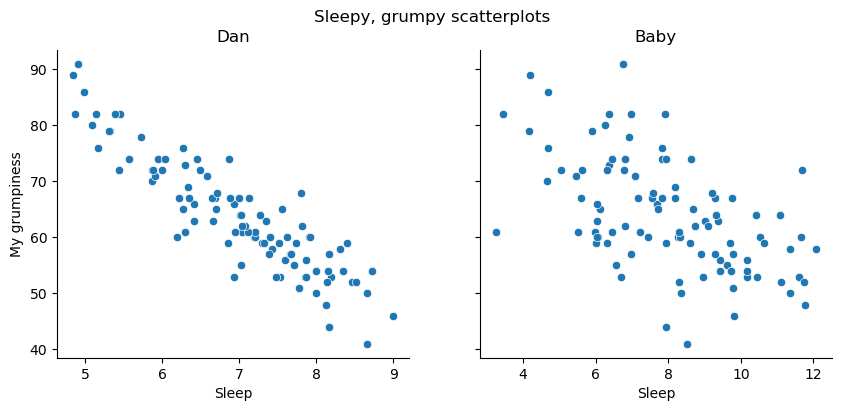

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
fig.suptitle('Sleepy, grumpy scatterplots')

sns.scatterplot(x=parenthood['dan_sleep'], y=parenthood['dan_grump'], ax=axes[0])
fig.axes[0].set_title("Dan")
fig.axes[0].set_xlabel("Sleep")
fig.axes[0].set_ylabel("My grumpiness")

sns.scatterplot(x=parenthood['baby_sleep'], y=parenthood['dan_grump'], ax=axes[1])
fig.axes[1].set_title("Baby")
fig.axes[1].set_xlabel("Sleep")
fig.axes[1].set_ylabel("My grumpiness")

sns.despine()

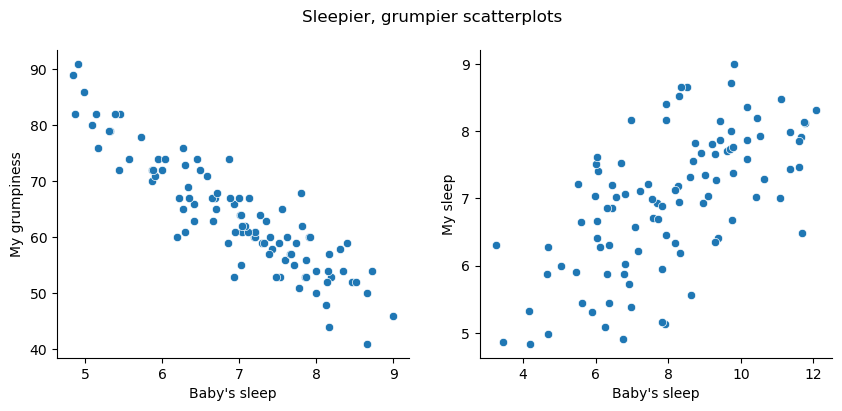

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False) # y axes are now on different scales, so sharey=False
fig.suptitle('Sleepier, grumpier scatterplots')

sns.scatterplot(x = parenthood['dan_sleep'], y = parenthood['dan_grump'], ax = axes[0])
fig.axes[0].set_xlabel("Baby's sleep")
fig.axes[0].set_ylabel("My grumpiness")

sns.scatterplot(x = parenthood['baby_sleep'], y = parenthood['dan_sleep'], ax = axes[1])
fig.axes[1].set_xlabel("Baby's sleep")
fig.axes[1].set_ylabel("My sleep")

sns.despine()

### 3.1 Pearson’s correlation coefficient

In [77]:
x = parenthood['dan_sleep']
y = parenthood['dan_grump']

print(x.corr(y)) 

-0.9033840374657273


In [80]:
# Covariance
print(x.cov(y))

-9.222921212121216


##### `column အကုန်လုံး တပြိုင်နက်တည်း ရှာလို့လည်း ရတယ်`

In [82]:
# Correlation Matrix
parenthood.corr()

,dan_sleep,baby_sleep,dan_grump,day
dan_sleep,1.000000,0.627949,-0.903384,-0.098408
baby_sleep,0.627949,1.000000,-0.565964,-0.010434
dan_grump,-0.903384,-0.565964,1.000000,0.076479
day,-0.098408,-0.010434,0.076479,1.000000


In [84]:
# Covariance Matrix
parenthood.cov()

,dan_sleep,baby_sleep,dan_grump,day
dan_sleep,1.032021,1.323202,-9.222921,-2.900303
baby_sleep,1.323202,4.302438,-11.797709,-0.627879
dan_grump,-9.222921,-11.797709,100.995859,22.297980
day,-2.900303,-0.627879,22.297980,841.666667


### 3.2 Spearman’s Rank Correlation

In [85]:
data = {
    'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'Knowledge_Score': [1, 4, 9, 16, 25, 36, 49, 64] # x squared
}
df_curve = pd.DataFrame(data)
df_curve

,Study_Hours,Knowledge_Score
0,1,1
1,2,4
2,3,9
3,4,16
4,5,25
5,6,36
6,7,49
7,8,64


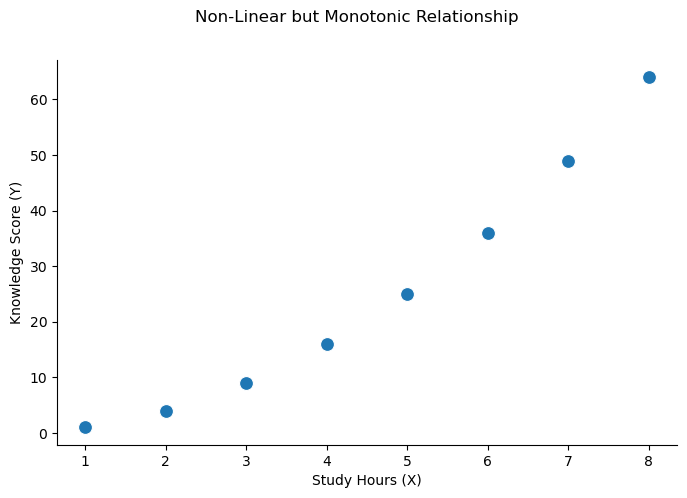

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Non-Linear but Monotonic Relationship')

sns.scatterplot(x=df_curve['Study_Hours'], y=df_curve['Knowledge_Score'], ax=ax, s=100)

ax.set_xlabel("Study Hours (X)")
ax.set_ylabel("Knowledge Score (Y)")

sns.despine()
plt.show()

In [90]:
pearson = df_curve['Study_Hours'].corr(df_curve['Knowledge_Score'], method='pearson')
spearman = df_curve['Study_Hours'].corr(df_curve['Knowledge_Score'], method='spearman')

print(f"Pearson Correlation:  {pearson:.4f}")
print(f"Spearman Correlation: {spearman:.4f}) # perfect relation")

Pearson Correlation:  0.9762
Spearman Correlation: 1.0000) # perfect relation
